In [1]:
from __future__ import annotations
import math
import random
import networkx as nx
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RXGate,RYGate
from classical_runtime_guarantee_util import mvc_exact_cplex, mvc_lp_relaxation, greedy_degree_vertex_cover, greedy_edge_vertex_cover,mvc_primal_dual_weighted
from quantum_greedy_util import expectation_value_cost_shifted
# ----------------------
# Mixer construction
# ----------------------
def node_order_by_cost_degree(G, C):
    """Order nodes by descending cost and degree."""
    return sorted(G.nodes(), key=lambda i: (-C[i], G.degree(i)))

def mixer_from_graph(G, C, node_order=None, p=1):
    """Construct QAOA-style mixer circuit for MVC."""
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    for i in range(n):
        qc.x(i)

    if node_order is None:
        node_order = node_order_by_cost_degree(G, C)

    for _ in range(p):
        for tgt in node_order:
            angle = 2 * betas[tgt] / p
            ctrls = list(G.neighbors(tgt))
            if ctrls:
                qc.append(RYGate(angle).control(len(ctrls)), ctrls + [tgt])
            else:
                qc.ry(angle, tgt)

    return qc, betas, G



from collections import defaultdict
def conditional_smc_mvc(G, beta_values, C, k=1, node_order=None, num_particles=100):
    """
    Sequential Monte Carlo along quantum tree, returns expectation value directly
    """
    if node_order is None:
        node_order = list(G.nodes())

    # Initialize particles: all vertices in cover
    particles = [{v: 1 for v in G.nodes()} for _ in range(num_particles)]

    for _ in range(k):
        for v in node_order:
            theta_v = beta_values[v]/k
            cos2 = math.cos(theta_v)**2
            sin2 = math.sin(theta_v)**2

            for p in range(num_particles):
                assigned = particles[p]

                # Check if removal is allowed (all neighbors still in cover)
                removable = all(assigned[u] == 1 for u in G.neighbors(v))

                if removable:
                    # Branch according to quantum amplitudes
                    choice = random.choices([1, 0], weights=[cos2, sin2])[0]
                else:
                    choice = 1

                assigned[v] = choice



    # Compute expectation value directly
    exp_val = 0.0
    for p in range(num_particles):
        particle_cost = sum(C[v] for v, val in particles[p].items() if val == 1)
        exp_val += particle_cost/num_particles
    

    weights = np.ones(num_particles)  # Uniform weights since we compute expectation directly
    return exp_val, particles
def greedy_mc_optimize_seq_with_cover(G, C, beta_values, node_order=None, num_particles=100):
    """
    Sequential greedy optimization (fixed order) using conditional SMC marginals.
    Returns:
        - optimized beta values
        - most probable vertex cover after optimization
        - weighted marginals per vertex
    Ensures final cover is feasible.
    """
    if node_order is None:
        node_order = node_order_by_cost_degree(G, C)

    beta_opt = beta_values.copy()

    # Step 1: sequential greedy optimization
    for v in node_order:
        candidates = [0.0, math.pi/2]
        best_beta = beta_opt[v]
        best_E = None

        for cand in candidates:
            trial = beta_opt.copy()
            trial[v] = cand
            E,particles=conditional_smc_mvc(G, beta_values, C, k=1, node_order=node_order, num_particles=num_particles)

            if best_E is None or E < best_E:
                best_E = E
                best_beta = cand

            beta_opt[v] = best_beta

    # Step 2: conditional SMC to get final cover
    E,particles=conditional_smc_mvc(G, beta_opt, C, k=1, node_order=node_order, num_particles=num_particles)
    final_cover=particles
    # Step 3: feasibility check
    uncovered_edges = [e for e in G.edges() if e[0] not in final_cover and e[1] not in final_cover]
    if uncovered_edges:
        print("Warning: some edges were uncovered in final cover, fixing greedily.")
        for u, v in uncovered_edges:
            if u not in final_cover:
                final_cover.append(u)
            if v not in final_cover:
                final_cover.append(v)

    return E, final_cover


def greedy_optimize_vertex_elimination_n2(
    G,
    c,
    C,
    beta_values_init,
    p=1,
    node_order=None,
    shots=None
):
    n = G.number_of_nodes()
    betas = {i: Parameter(f"β_{i}") for i in range(n)}

    values = beta_values_init.copy()
    unfixed = list(range(n))
    fixed = []
    global_energy=np.inf
    global_vertices=None
    while unfixed:
        best_vertex = None
        best_value = None
        if len(unfixed)==n:
            best_energy=np.inf
        else:
            best_energy = np.inf

        improvement_found = False

        for v in unfixed:

            trial_vals = values.copy()
            trial_vals[v] = 0   # or try both 0 and 1 if needed

            E,particles=conditional_smc_mvc(G, trial_vals, C, k=1, node_order=node_order, num_particles=shots)
            #print(E,v)

            if E < best_energy:  # strictly better
                best_energy = E
                best_value = 0
                best_vertex = v
                improvement_found = True
        #print(best_vertex)
        # STOP CONDITION
        '''
        if not improvement_found:
            print("No further improvement possible. Stopping.")
            break
        '''
        if best_energy<global_energy:
            global_energy=best_energy
            global_vertices=values

        # Apply best move
        values[best_vertex] = best_value
        fixed.append(best_vertex)
        unfixed.remove(best_vertex)
    print(global_energy)
    return global_vertices,global_energy

    

In [2]:
def greedy_optimize_vertex_elimination_n2_reduced(
    G,
    C,
    beta_values_init,
    node_order=None,
    p=1,
    shots=None,
):
    G = nx.convert_node_labels_to_integers(G)
    
    # Keep original labels mapping
    original_nodes = list(G.nodes())
    
    values = beta_values_init.copy()
    global_energy = np.inf
    global_vertices = values.copy()
    
    current_graph = G.copy()
    
    while current_graph.number_of_nodes() > 0:
        
        n = current_graph.number_of_nodes()
        current_nodes = list(current_graph.nodes())
        
        # Rebuild parameters only for active nodes
        betas = {i: Parameter(f"β_{i}") for i in current_nodes}
        C = {i: 1.0 for i in current_graph.nodes()}
        new_order=node_order_by_cost_degree(current_graph,C)
        # Build mixer on reduced graph

        best_energy = np.inf
        best_vertex = None

        for v in current_nodes:

            trial_vals = values.copy()
            trial_vals[v] = 0
            E,particles=conditional_smc_mvc(current_graph, trial_vals, C, k=1, node_order=new_order, num_particles=shots)
            E=E+len(beta_values_init)-len(current_graph.nodes())

            if E < best_energy:
                best_energy = E
                best_vertex = v

        # Update global best
        if best_energy < global_energy:
            global_energy = best_energy
            global_vertices = values.copy()

        # Fix chosen vertex
        del values[len(current_graph.nodes())-1]  # Remove last entry which corresponds to the removed vertex

        # Remove vertex from graph (and all edges)
        current_graph.remove_node(best_vertex)
        #print(best_vertex)
        #print(current_graph.nodes())
        #print(current_graph.edges())
        mapping = {old: new for new, old in enumerate(current_graph.nodes())}
        current_graph = nx.relabel_nodes(current_graph, mapping)
        #print(current_graph.nodes())
        #print(current_graph.edges())
    print("Global energy:", global_energy)
    return global_energy

In [3]:
G = nx.random_regular_graph(3,10)
C = {v: 1 for v in G.nodes()}
beta_values = {v: math.pi/2 for v in G.nodes()}
node_order=node_order_by_cost_degree(G, C)
result = greedy_optimize_vertex_elimination_n2_reduced(
    G,
    C,
    beta_values,
    p=1,
    node_order=node_order,
    shots=1000
)
print(result)
C_opt = mvc_exact_cplex(G, C)
opt_cost = sum(C[i] for i in C_opt)
print(f"Optimal cost: {opt_cost}")

Global energy: 5.999999999999915
5.999999999999915
Optimal cost: 6


In [4]:
import networkx as nx
import math
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Experiment parameters
# -----------------------------
sizes = [20, 40, 60, 80,100]
k = 10                   # number of random graphs per size
degree = 3                # random regular graph degree
shots = 5000

mean_ratios = []
std_ratios = []

# -----------------------------
# Experiment loop
# -----------------------------
for n in sizes:

    ratios = []

    for trial in range(k):
        print(f"Running n={n}, trial={trial+1}/{k}")

        # Generate graph
        G = nx.random_regular_graph(degree, n)

        # Costs and parameters
        C = {v: 1 for v in G.nodes()}
        beta_values = {v: math.pi/2 for v in G.nodes()}

        node_order = node_order_by_cost_degree(G, C)

        # --- heuristic solution ---
        approx_cost = greedy_optimize_vertex_elimination_n2_reduced(
            G,
            C,
            beta_values,
            p=1,
            node_order=node_order,
            shots=shots
        )

        # --- optimal solution ---
        C_opt = mvc_exact_cplex(G, C)
        opt_cost = sum(C[v] for v in C_opt)

        ratio = approx_cost / opt_cost
        ratios.append(ratio)

        print(f"  approx={approx_cost}, opt={opt_cost}, ratio={ratio:.3f}")

    mean_ratios.append(np.mean(ratios))
    std_ratios.append(np.std(ratios))

# -----------------------------
# Plot
# -----------------------------
plt.figure()

plt.errorbar(
    sizes,
    mean_ratios,
    yerr=std_ratios,
    marker='o',
    capsize=5
)

plt.xlabel("Graph size (n)")
plt.ylabel("Approximation ratio (C_approx / C_opt)")
plt.title("Approximation Ratio vs Graph Size")

plt.grid(True)
plt.show()

Running n=20, trial=1/10
Global energy: 11.999999999999247
  approx=11.999999999999247, opt=12, ratio=1.000
Running n=20, trial=2/10
Global energy: 11.999999999999247
  approx=11.999999999999247, opt=12, ratio=1.000
Running n=20, trial=3/10
Global energy: 11.999999999999382
  approx=11.999999999999382, opt=12, ratio=1.000
Running n=20, trial=4/10
Global energy: 11.999999999999247
  approx=11.999999999999247, opt=12, ratio=1.000
Running n=20, trial=5/10
Global energy: 10.999999999999623
  approx=10.999999999999623, opt=11, ratio=1.000
Running n=20, trial=6/10
Global energy: 10.999999999999382
  approx=10.999999999999382, opt=11, ratio=1.000
Running n=20, trial=7/10
Global energy: 11.999999999999247
  approx=11.999999999999247, opt=12, ratio=1.000
Running n=20, trial=8/10
Global energy: 11.999999999999247
  approx=11.999999999999247, opt=12, ratio=1.000
Running n=20, trial=9/10
Global energy: 10.999999999999382
  approx=10.999999999999382, opt=11, ratio=1.000
Running n=20, trial=10/10
Gl

KeyboardInterrupt: 

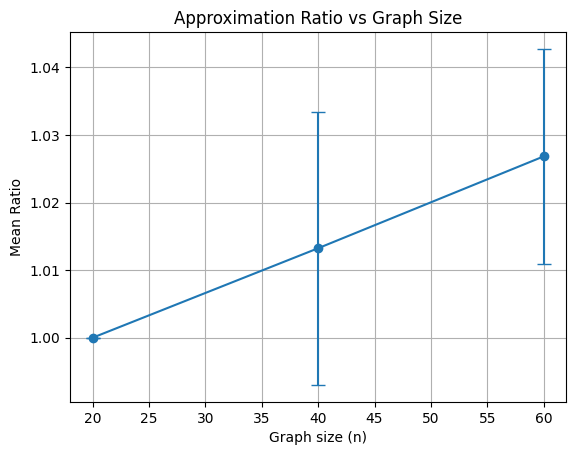

In [5]:
plt.figure()

plt.errorbar(
    [20,40,60],
    mean_ratios,
    yerr=std_ratios,
    marker='o',
    capsize=5
)

plt.xlabel("Graph size (n)")
plt.ylabel("Mean Ratio")
plt.title("Approximation Ratio vs Graph Size")

plt.grid(True)
plt.show()